In [38]:
import os
import json
import xml.etree.ElementTree as ET

def extract_paper_data(xml_file_path):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()
    papers = {}

    for record in root.findall('.//r/*'):  # <article>, <inproceedings>, etc.
        key = record.attrib.get("key")
        title_elem = record.find("title")
        year_elem = record.find("year")
        authors = record.findall("author")

        if not key or title_elem is None or year_elem is None or not authors:
            continue

        papers[key] = {
            "title": title_elem.text.strip() if title_elem.text else "",
            "year": year_elem.text.strip() if year_elem.text else "",
            "authors": [
                {
                    "pid": a.attrib.get("pid", ""),
                    "name": a.text.strip() if a.text else ""
                } for a in authors
            ]
        }

    return papers

def process_faculty_folder(folder_path, output_path):
    papers_by_key = {}

    for filename in os.listdir(folder_path):
        if filename.endswith(".xml"):
            xml_path = os.path.join(folder_path, filename)
            papers_by_key.update(extract_paper_data(xml_path))

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(papers_by_key, f, indent=2, ensure_ascii=False)

    print(f"✅ Extracted paper data saved to: {output_path}")

# --- Run this ---
folder_path = r"C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty\faculty_data"
output_json_path = r"C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty\papers_by_key.json"

process_faculty_folder(folder_path, output_json_path)


✅ Extracted paper data saved to: C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty\papers_by_key.json


In [40]:
import json

def deduplicate_paper_data(input_path, output_path):
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    cleaned_data = {}

    for key, paper in data.items():
        seen_pids = set()
        unique_authors = []

        for author in paper.get("authors", []):
            pid = author.get("pid")
            if pid and pid not in seen_pids:
                seen_pids.add(pid)
                unique_authors.append(author)

        cleaned_data[key] = {
            "title": paper.get("title", ""),
            "year": paper.get("year", ""),
            "authors": unique_authors
        }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(cleaned_data, f, indent=2, ensure_ascii=False)

    print(f"✅ Cleaned JSON saved to: {output_path}")

# --- Run this ---
input_json = r"C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty\papers_by_key.json"
output_json = r"C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty\papers_by_key_cleaned.json"

deduplicate_paper_data(input_json, output_json)


✅ Cleaned JSON saved to: C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty\papers_by_key_cleaned.json


In [44]:
import json
import networkx as nx
import pandas as pd

# Define file paths
base_path = r"C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty"
papers_file = base_path + r"\papers_by_key_cleaned.json"
main_authors_file = base_path + r"\main_authors.json"

# Load data
with open(papers_file, "r", encoding="utf-8") as f:
    papers = json.load(f)

with open(main_authors_file, "r", encoding="utf-8") as f:
    main_authors_data = json.load(f)

# Extract main author pids
main_author_pids = {author['pid'] for author in main_authors_data}

# Build co-authorship graph
G = nx.Graph()
pid_to_name = {}

for paper in papers.values():
    pids = [author["pid"] for author in paper["authors"]]
    for author in paper["authors"]:
        pid_to_name[author["pid"]] = author["name"]
    for i in range(len(pids)):
        for j in range(i + 1, len(pids)):
            G.add_edge(pids[i], pids[j])

# Helper to get top nodes
def get_top_nodes(centrality_dict, exclude_pids, top_n=1000):
    filtered = {pid: score for pid, score in centrality_dict.items() if pid not in exclude_pids}
    return sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:top_n]

# Compute and save Degree Centrality
degree_centrality = nx.degree_centrality(G)
top_degree = get_top_nodes(degree_centrality, main_author_pids)
df_degree = pd.DataFrame([
    {"pid": pid, "name": pid_to_name.get(pid, "Unknown"), "degree_score": score}
    for pid, score in top_degree
])
df_degree.to_csv(base_path + r"\top_1000_degree_centrality.csv", index=False)

# Compute and save PageRank
pagerank = nx.pagerank(G)
top_pagerank = get_top_nodes(pagerank, main_author_pids)
df_pagerank = pd.DataFrame([
    {"pid": pid, "name": pid_to_name.get(pid, "Unknown"), "pagerank_score": score}
    for pid, score in top_pagerank
])
df_pagerank.to_csv(base_path + r"\top_1000_pagerank.csv", index=False)

print("CSV files saved successfully:")
print("- top_1000_degree_centrality.csv")
print("- top_1000_pagerank.csv")


CSV files saved successfully:
- top_1000_degree_centrality.csv
- top_1000_pagerank.csv


In [50]:
import json
import networkx as nx
import pandas as pd

# Define file paths
base_path = r"C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty"
papers_file = base_path + r"\papers_by_key_cleaned.json"
main_authors_file = base_path + r"\main_authors.json"

# Load data
with open(papers_file, "r", encoding="utf-8") as f:
    papers = json.load(f)

with open(main_authors_file, "r", encoding="utf-8") as f:
    main_authors_data = json.load(f)

# Extract main author pids
main_author_pids = {author['pid'] for author in main_authors_data}

# Build co-authorship graph with weights
G = nx.Graph()
pid_to_name = {}

for paper in papers.values():
    pids = [author["pid"] for author in paper["authors"]]
    for author in paper["authors"]:
        pid_to_name[author["pid"]] = author["name"]
    for i in range(len(pids)):
        for j in range(i + 1, len(pids)):
            pid1, pid2 = pids[i], pids[j]
            if G.has_edge(pid1, pid2):
                G[pid1][pid2]['weight'] += 1
            else:
                G.add_edge(pid1, pid2, weight=1)

# Helper to get top nodes
def get_top_nodes(centrality_dict, exclude_pids, top_n=1000):
    filtered = {pid: score for pid, score in centrality_dict.items() if pid not in exclude_pids}
    return sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:top_n]

# Weighted Degree Centrality (not normalized)
weighted_degree = {node: sum(weight for _, _, weight in G.edges(node, data='weight')) for node in G.nodes}
top_degree = get_top_nodes(weighted_degree, main_author_pids)
df_degree = pd.DataFrame([
    {"pid": pid, "name": pid_to_name.get(pid, "Unknown"), "weighted_degree": score}
    for pid, score in top_degree
])
df_degree.to_csv(base_path + r"\top_1000_weighted_degree.csv", index=False)

# Weighted PageRank
pagerank = nx.pagerank(G, weight='weight')
top_pagerank = get_top_nodes(pagerank, main_author_pids)
df_pagerank = pd.DataFrame([
    {"pid": pid, "name": pid_to_name.get(pid, "Unknown"), "pagerank_score": score}
    for pid, score in top_pagerank
])
df_pagerank.to_csv(base_path + r"\top_1000_weighted_pagerank.csv", index=False)

# -------- Filter the graph to keep only top 1000 pagerank + main authors --------
top_1000_pagerank_pids = {pid for pid, _ in top_pagerank}
nodes_to_keep = top_1000_pagerank_pids.union(main_author_pids)
nodes_to_remove = set(G.nodes()) - nodes_to_keep

G.remove_nodes_from(nodes_to_remove)

# Optional: Save the filtered graph as GraphML or GEXF (for Gephi visualization)
nx.write_graphml(G, base_path + r"\filtered_collab_network.graphml")
# Or save in another format:
# nx.write_gexf(G, base_path + r"\filtered_collab_network.gexf")

print("CSV files saved successfully:")
print("- top_1000_weighted_degree.csv")
print("- top_1000_weighted_pagerank.csv")
print("Filtered graph saved as 'filtered_collab_network.graphml'")


CSV files saved successfully:
- top_1000_weighted_degree.csv
- top_1000_weighted_pagerank.csv
Filtered graph saved as 'filtered_collab_network.graphml'


In [60]:
import networkx as nx

# Load filtered graph
graphml_path = r"C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty\filtered_collab_network.graphml"
G = nx.read_graphml(graphml_path)

# Basic stats
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Clustering coefficient
clustering_coeff = nx.average_clustering(G)

# Handle disconnected graphs for distance
if nx.is_connected(G):
    avg_shortest_path = nx.average_shortest_path_length(G)
else:
    largest_cc = max(nx.connected_components(G), key=len)
    subgraph = G.subgraph(largest_cc)
    avg_shortest_path = nx.average_shortest_path_length(subgraph)

# Average degree
avg_degree = sum(dict(G.degree()).values()) / num_nodes

# Print results
print(f"📌 Graph Statistics:")
print(f"- Number of nodes: {num_nodes}")
print(f"- Number of edges: {num_edges}")
print(f"- Average clustering coefficient: {clustering_coeff:.4f}")
print(f"- Average shortest path length (largest component): {avg_shortest_path:.4f}")
print(f"- Average degree: {avg_degree:.2f}")


📌 Graph Statistics:
- Number of nodes: 1109
- Number of edges: 9016
- Average clustering coefficient: 0.5209
- Average shortest path length (largest component): 3.0995
- Average degree: 16.26


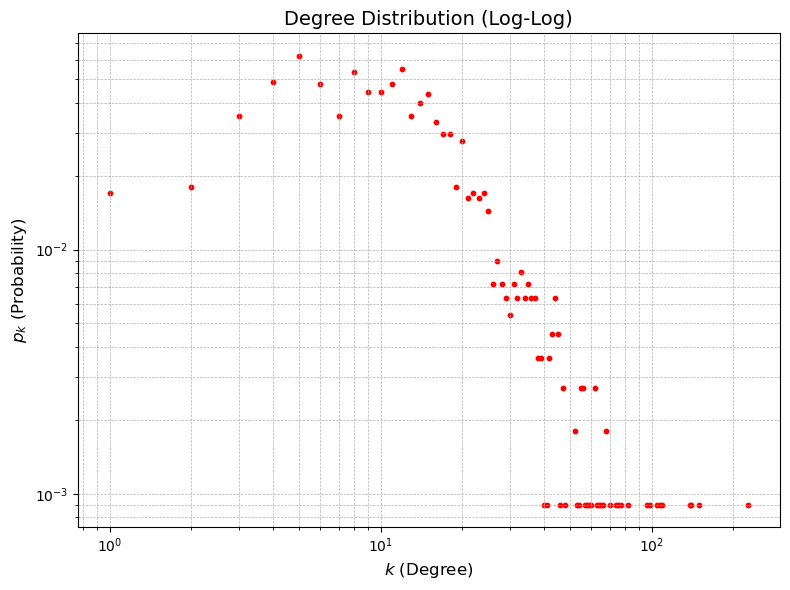

In [62]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Load your filtered graph
graphml_path = r"C:\Users\tuanl\collaboration-network-of-NTU-CCDS-faculty\filtered_collab_network.graphml"
G = nx.read_graphml(graphml_path)

# Compute degree distribution
degrees = [d for _, d in G.degree()]
degree_count = Counter(degrees)

# Prepare data for plotting
k = np.array(list(degree_count.keys()))
pk = np.array(list(degree_count.values())) / sum(degree_count.values())  # normalize to get probabilities

# Sort by degree
sorted_idx = np.argsort(k)
k = k[sorted_idx]
pk = pk[sorted_idx]

# Plot on log-log scale
plt.figure(figsize=(8, 6))
plt.scatter(k, pk, color='red', label='Empirical', s=10)
plt.plot(k, pk, linestyle='None')  # dotted line optional

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$k$ (Degree)", fontsize=12)
plt.ylabel(r"$p_k$ (Probability)", fontsize=12)
plt.title("Degree Distribution (Log-Log)", fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()
